In [11]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [12]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

house_prices_advanced_regression_techniques_path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print('Data source import complete.')


Data source import complete.


In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 34.0 Competition Selection
Selection Rationale

The House Prices: Advanced Regression Techniques competition was chosen because it represents a classic, highly structured tabular dataset ideal for tree-based supervised machine learning.

- **Algorithm Fit**: Decision Trees, Random Forests, Gradient Boosting, XGBoost, and LightGBM perform exceptionally well on non-linear tabular features without requiring strict feature scaling.

- **Practical Features**: Contains 79 explanatory variables representing almost every aspect of residential homes (e.g., square footage, quality ratings, build year, neighborhood).

- **Continuous Target**: The continuous target variable (SalePrice) requires regression techniques, making error evaluation straightforward using Root Mean Squared Error (RMSE) on log-transformed values.

# 35.0 Objective and Evaluation Metric Competition Objective
- The goal is to predict the final transaction price (SalePrice) of residential homes in Ames, Iowa, based on 79 property attributes.Evaluation MetricSubmissions are evaluated using Root Mean Squared Logarithmic Error (RMSLE) between the predicted value and the actual sale price:$$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \log(y_i + 1) - \log(\hat{y}_i + 1) \right)^2}$$Note: Taking the logarithm ensures that errors in predicting expensive houses and cheap houses affect the score equally.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set file paths
DATA_PATH = "/root/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques"

# Load datasets
train_df = pd.read_csv(f"{DATA_PATH}/train.csv")
test_df = pd.read_csv(f"{DATA_PATH}/test.csv")
sample_sub = pd.read_csv(f"{DATA_PATH}/sample_submission.csv")

# Display dimensions and sample data
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape:  {test_df.shape}")
train_df.head(3)

Train Shape: (1460, 81)
Test Shape:  (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [15]:
# Inspect missing values and column data types
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# 37.0 Data Cleaning and Exploratory Data Analysis (EDA)
Log-Transforming the Target Variable

Because SalePrice is right-skewed, applying np.log1p normalizes the distribution to directly optimize the competition's RMSLE metric.

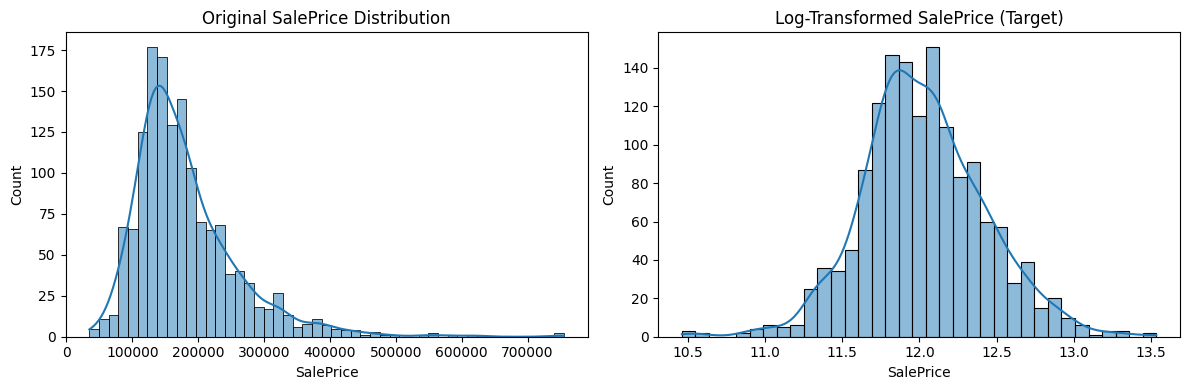

In [16]:
# Target distribution before and after log transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train_df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title("Original SalePrice Distribution")

sns.histplot(np.log1p(train_df['SalePrice']), kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed SalePrice (Target)")

plt.tight_layout()
plt.show()

# Apply log transformation to target
y = np.log1p(train_df['SalePrice'])
X_train_raw = train_df.drop(columns=['Id', 'SalePrice'])
X_test_raw = test_df.drop(columns=['Id'])

## 37.1 Missing Data Handling

Certain missing values represent the absence of a feature rather than missing information (e.g., NA in PoolQC means "No Pool").

In [17]:
# Combine train and test for consistent preprocessing
combined = pd.concat([X_train_raw, X_test_raw], axis=0).reset_index(drop=True)

# Categorical columns where NA means 'None'
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarType', 'GarFinish', 'GarQual', 'GarCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

for col in none_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna('None')

# Numerical columns where NA means 0
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
             'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']

for col in zero_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna(0)

# Impute remaining numeric values with median and categorical with mode
num_cols = combined.select_dtypes(include=[np.number]).columns
cat_cols = combined.select_dtypes(include=['object']).columns

for col in num_cols:
    combined[col] = combined[col].fillna(combined[col].median())

for col in cat_cols:
    combined[col] = combined[col].fillna(combined[col].mode()[0])

print(f"Remaining Missing Values: {combined.isnull().sum().sum()}")

Remaining Missing Values: 0


# 38.0 Feature Engineering

Creating domain-specific features improves performance for tree models.

In [18]:
# Create total square footage feature
combined['TotalSF'] = combined['TotalBsmtSF'] + combined['1stFlrSF'] + combined['2ndFlrSF']

# Calculate property age at time of sale
combined['HouseAge'] = combined['YrSold'] - combined['YearBuilt']
combined['RemodAge'] = combined['YrSold'] - combined['YearRemodAdd']

# Total bathroom count
combined['TotalBaths'] = combined['FullBath'] + (0.5 * combined['HalfBath']) + \
                        combined['BsmtFullBath'] + (0.5 * combined['BsmtHalfBath'])

# Convert remaining categorical features to dummy/one-hot encoding
combined_encoded = pd.get_dummies(combined, drop_first=True)

# Split back to train and test sets
n_train = len(y)
X_train = combined_encoded.iloc[:n_train].copy()
X_test = combined_encoded.iloc[n_train:].copy()

print(f"Processed Train Shape: {X_train.shape}")
print(f"Processed Test Shape:  {X_test.shape}")

Processed Train Shape: (1460, 258)
Processed Test Shape:  (1459, 258)


# 39.0 Baseline Model

Establish a simple baseline model using a single Decision Tree Regressor.

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

baseline_model = DecisionTreeRegressor(random_state=42)
baseline_scores = cross_val_score(
    baseline_model, X_train, y,
    cv=5, scoring='neg_root_mean_squared_error'
)

baseline_rmse = -np.mean(baseline_scores)
print(f"Baseline Decision Tree 5-Fold CV RMSE: {baseline_rmse:.4f}")

Baseline Decision Tree 5-Fold CV RMSE: 0.2126


# 40.0 Multi-Model Training

Train three additional tree-based algorithms: Random Forest, Gradient Boosting, XGBoost, and LightGBM.

In [20]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
}

# 41.0 Model Comparison and Validation

Compare model accuracy using 5-Fold Cross-Validation evaluated on Root Mean Squared Error (RMSE).

In [21]:
results = {"Decision Tree Baseline": baseline_rmse}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y, cv=5, scoring='neg_root_mean_squared_error')
    rmse_score = -np.mean(scores)
    results[name] = rmse_score

# Convert results to DataFrame
comparison_df = pd.DataFrame(list(results.items()), columns=['Model', '5-Fold CV RMSE']).sort_values('5-Fold CV RMSE')
comparison_df

,Model,5-Fold CV RMSE
2,Gradient Boosting,0.128033
4,LightGBM,0.132635
3,XGBoost,0.140307
1,Random Forest,0.144063
0,Decision Tree Baseline,0.212641


# 42.0 Hyperparameter Tuning

Tune the best-performing model (e.g., XGBoost Regressor) using GridSearchCV.

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y)

best_model = grid_search.best_estimator_
best_score = -grid_search.best_score_

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned XGBoost CV RMSE: {best_score:.4f}")

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Tuned XGBoost CV RMSE: 0.1258


# 43.0 Generate Kaggle Submission File

Predict on the unseen test set, apply np.expm1 to reverse log transformation, and format the final output.

In [23]:
# Predict on test data using tuned best model
test_predictions_log = best_model.predict(X_test)

# Convert predictions back to original scale (dollars)
test_predictions = np.expm1(test_predictions_log)

# Create submission dataframe
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_predictions
})

# Save to CSV
submission.to_csv("submission.csv", index=False)
submission.head()

,Id,SalePrice
0,1461,123064.890625
1,1462,158000.656250
2,1463,185802.031250
3,1464,190104.312500
4,1465,186995.375000


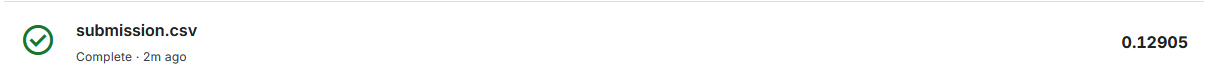